In [1]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from scdepth import pl, fn, fit
from scipy import stats
import glob, os
from collections import Counter

In [12]:
cdf = pd.read_csv('../data/cohort.csv')
adf = pd.read_csv('../data/cohort_annotations.csv')
sudf = pd.read_csv('../data/Table_S1.csv')
sudf = sudf[['sample','cells_or_tissue_frac']].copy()


dfs = []
for i, r in cdf.iterrows():
    ch = r.dataset
    if not os.path.isfile(f'../{ch}/{r["sample"]}/scdepth_fit_baseline.txt'):
        continue
        
    bdf = pd.read_csv(f'../{ch}/{r["sample"]}/scdepth_fit_baseline.txt', sep='\t')
    dfs.append(bdf)
df = pd.concat(dfs)
cdf = cdf.merge(df, left_on='sample', right_on='sample', how='left')
cdf = cdf.merge(adf, left_on=['group','subgroup'], right_on=['group','subgroup'], how='left')
cdf = cdf.merge(sudf, left_on='sample', right_on='sample', how='left')
cdf['L_norm'] = cdf['nb_lib_L'] / cdf['cells_or_tissue_frac']
cdf['align_rate'] = cdf['countable_reads'] / cdf['total_reads']

In [65]:
markers_map = {
    "PBMC_scrna": "o",
    "PBMC_scrna_flex": "o",
    "visium_hd": "s",
    "OvaryCA_CD45p": "^",
    "OvaryCA_CD45m": "v",
    "Heart": "P",
    "visium": "X",
    "Brain": "D",
    "Colon": "h",
    "Melanoma": "*",
}



In [19]:
cdf = cdf[cdf['group'] != 'visium'].copy()
cdf[['group','subgroup']].value_counts()

group            subgroup    
OvaryCA_CD45p    10X_3p_v3       20
OvaryCA_CD45m    10X_3p_v3       19
PBMC_scrna       10X_3p_v31      19
visium_hd        FFPE            15
Heart            10X_3p_v3       13
PBMC_scrna_flex  10X_flex_v1     11
PBMC_scrna       10X_3p_v4        9
Brain            10X_3p_v3        7
Colon            10X_5p_v2        6
PBMC_scrna       10X_3p_v3        6
visium_hd        Fresh_Frozen     6
                 Fixed_Frozen     3
Melanoma         10X_3p_v4        1
                 10X_5p_v2        1
                 10X_5p_v3        1
                 10X_3p_v31       1
PBMC_scrna       10X_5p_v3        1
                 10X_5p_v2        1
Name: count, dtype: int64

In [51]:
cdf.columns

Index(['sample', 'library_prep', 'dataset', 'group', 'subgroup', 'bam', 'gtf',
       'positions', 'probes', 'extra', 'fraction', 'reads', 'molecules',
       'reads_discarded', 'reads_excluded', 'downsampled_frac', 'saturation',
       'ztnb_rhat', 'ztnb_phat', 'ztnb_KS', 'ztnb_nll_per_mol',
       'ztnb_tail_mass', 'ztnb_error_flag', 'nb_lib_L',
       'nb_lib_saturation_MAE', 'nb_lib_recovery', 'countable_reads',
       'total_reads', 'full_saturation', 'full_reads', 'full_molecules',
       'spliced_reads', 'spliced_molecules', 'ambiguous_reads',
       'ambiguous_molecules', 'unspliced_reads', 'unspliced_molecules',
       'total_molecules', 'spliced_ztnb_rhat', 'spliced_ztnb_phat',
       'spliced_ztnb_KS', 'spliced_ztnb_nll_per_mol', 'spliced_ztnb_tail_mass',
       'spliced_ztnb_error_flag', 'spliced_nb_lib_L', 'ambiguous_ztnb_rhat',
       'ambiguous_ztnb_phat', 'ambiguous_ztnb_KS',
       'ambiguous_ztnb_nll_per_mol', 'ambiguous_ztnb_tail_mass',
       'ambiguous_ztnb_error_f

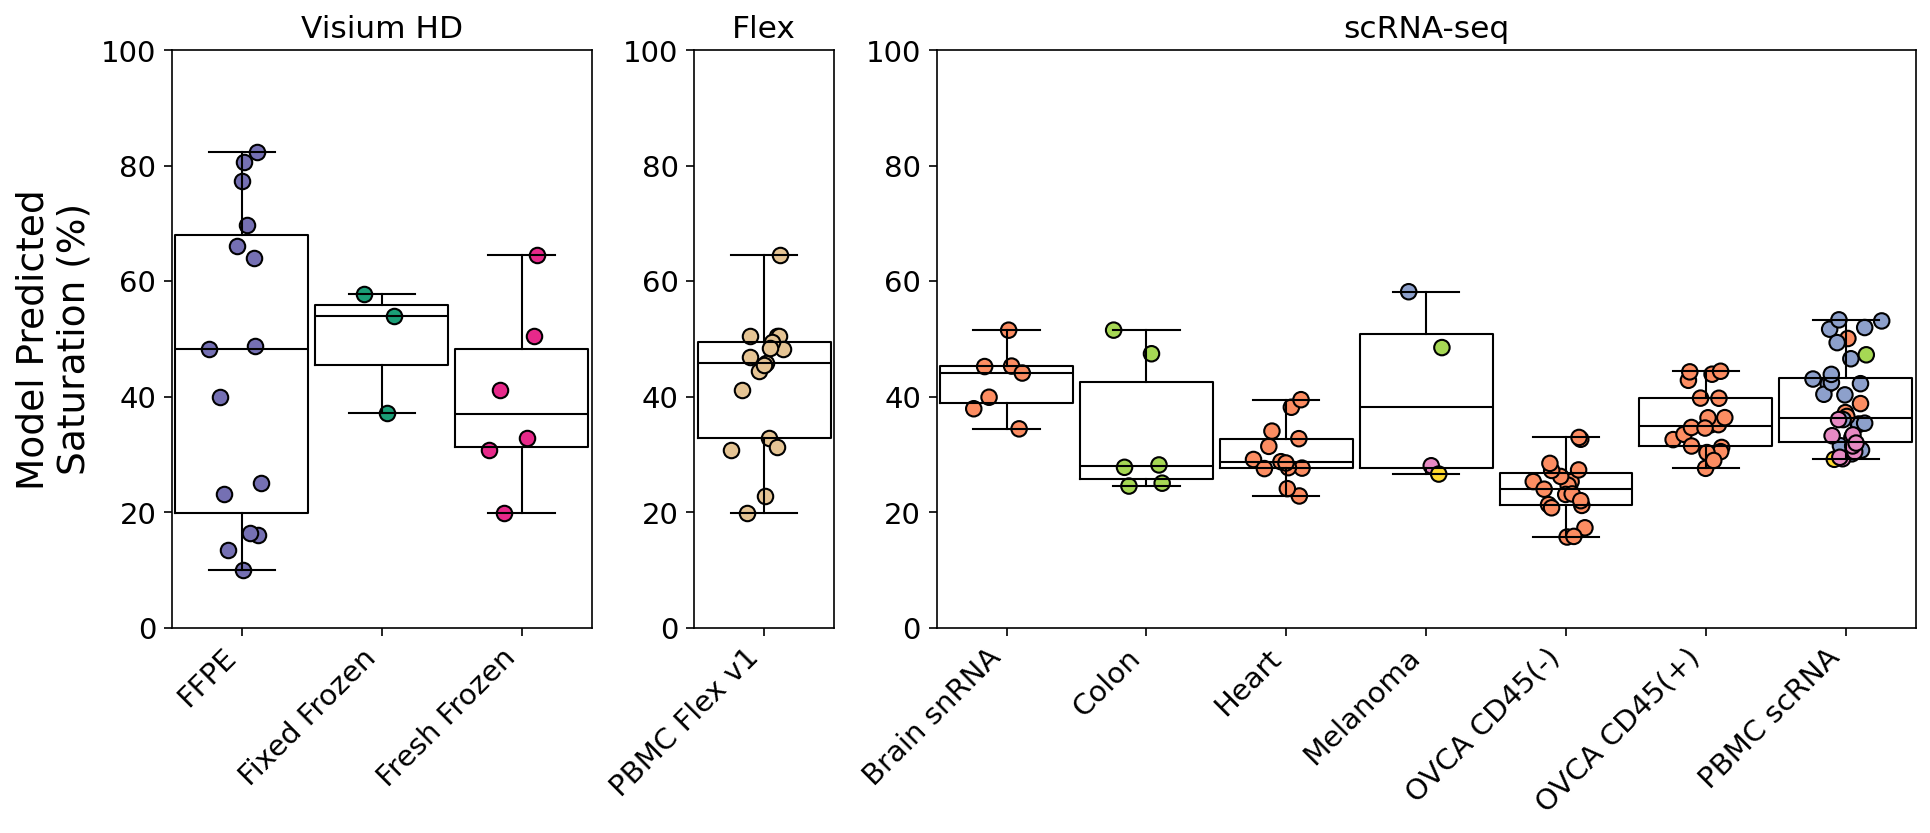

In [112]:
fig, axs = pl.figax(1, 3, s=5, width_ratios=[3, 1, 7])
fig.subplots_adjust(hspace=0.1)
seen = set()
for i, (grp, cost) in enumerate(zip(('FFPE', 'Fixed_Frozen', 'Fresh_Frozen'), (275000000, 500000000, 700000000))):
    sel = cdf[(cdf['group'] == 'visium_hd') & (cdf['subgroup'] == grp)]
    sp = []
    rp = []
    
    for s in sel.itertuples():   
        reads = int(cost * s.align_rate * s.cells_or_tissue_frac)
        ff = fit.NBLibFit(rhat=s.ztnb_rhat, phat=s.ztnb_phat, L=s.nb_lib_L)
        sat = ff.predict_saturation(reads)    
        sp.append(sat)
        
        seen.add(lab)
    lab = grp.replace('_', ' ')
    pl.jitter_box(axs[0], i, sp, s=55, color=s.color, edgecolor='k', lw=1)
    

axs[0].set_xticks(np.arange(3))
axs[0].set_xticklabels(('FFPE', 'Fixed Frozen', 'Fresh Frozen'), rotation=45, fontsize=12, ha='right')


sel = cdf[(cdf['group'] == 'PBMC_scrna_flex')]
for s in sel.itertuples():  
    reads = int(10000 * s.align_rate * s.cells_or_tissue_frac)
    ff = fit.NBLibFit(rhat=s.ztnb_rhat, phat=s.ztnb_phat, L=s.nb_lib_L)
    sat = ff.predict_saturation(reads)    
    sp.append(sat)

pl.jitter_box(axs[1], 0, sp, s=55, color=s.color, edgecolor='k', lw=1)
axs[1].set_xticklabels(['PBMC Flex v1'], rotation=45, ha='right')
sel = cdf[(cdf['group'] != 'PBMC_scrna_flex') & (cdf['group'] != 'visium_hd')]
xl = []
for i, (g, ss) in enumerate(sel.groupby('group')):
    sp = []
    rp = []    
    xl.append(ss.iloc[0].group_title)
    for s in ss.itertuples():  
        reads = int(20000 * s.align_rate * s.cells_or_tissue_frac)
        ff = fit.NBLibFit(rhat=s.ztnb_rhat, phat=s.ztnb_phat, L=s.nb_lib_L)
        sat = ff.predict_saturation(reads)    
        sp.append(sat)
    pl.jitter_box(axs[2], i, sp, s=55, color=ss['color'].values, edgecolor='k', lw=1)
axs[2].set_xticklabels([])
axs[2].set_xticklabels(xl, rotation=45, fontsize=12, ha='right')

for ax in axs.flatten():
    ax.set_ylim(0, 100)
    ax.tick_params(axis='both', labelsize=14)
    ax.tick_params(axis='both', which='both', length=4)
axs[0].set_ylabel('Model Predicted\nSaturation (%)', fontsize=18)
axs[0].set_title('Visium HD', fontsize=15)
axs[1].set_title('Flex', fontsize=15)
axs[2].set_title('scRNA-seq', fontsize=15)

fig.savefig('../Figures/Figure S5 Costs.svg', bbox_inches='tight')

In [ ]:

recommendations = {'PBMC_scrna_flex': 10000, 'visium_hd_FFPE':275000000, 
                   'visium_hd_Fresh_Frozen':700000000, 'visium_hd_Fixed_Frozen':500000000}

default = 20000